<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Projetos de Análise de Dados com Linguagem Python</font>
### <font color='blue'>Projeto 3 - Técnicas de Limpeza e Tratamento de Valores Ausentes Para Análise de Dados</font>
### <font color='blue'>Parte 2</font>

## Pacotes Python Usados no Projeto

In [6]:
!pip install -q -U watermark

In [7]:
# Imports
import math
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

In [8]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



## Carregando os Dados

https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

In [9]:
# Criamos uma lista para identificar valores ausentes
lista_labels_valores_ausentes = ["n/a", "na", "undefined"]

In [10]:
# Carrega o dataset
dataset_dsa = pd.read_csv("dataset.csv", na_values = lista_labels_valores_ausentes)

In [11]:
# Shape
dataset_dsa.shape

(150001, 55)

In [12]:
# Amostra de dados
dataset_dsa.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311448e+19,4/4/2019 12:01,770.0,4/25/2019 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16456699548519E+015,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311448e+19,4/9/2019 13:04,235.0,4/25/2019 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311448e+19,4/9/2019 17:42,1.0,4/25/2019 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311448e+19,4/10/2019 0:31,486.0,4/25/2019 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311448e+19,4/12/2019 20:10,565.0,4/25/2019 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [13]:
# Define o número total de colunas para mostrar ao imprimir o dataframe
pd.set_option('display.max_columns', 100)

In [14]:
# Amostra de dados
dataset_dsa.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311448e+19,4/4/2019 12:01,770.0,4/25/2019 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16456699548519E+015,42.0,5.0,23.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,37624.0,38787.0,1.823653e+09,Samsung,Samsung Galaxy A5 Sm-A520F,NaN,NaN,NaN,NaN,NaN,NaN,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311448e+19,4/9/2019 13:04,235.0,4/25/2019 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,168.0,3560.0,1.365104e+09,Samsung,Samsung Galaxy J5 (Sm-J530),NaN,NaN,NaN,NaN,NaN,NaN,971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311448e+19,4/9/2019 17:42,1.0,4/25/2019 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.361763e+09,Samsung,Samsung Galaxy A8 (2018),NaN,NaN,NaN,NaN,NaN,NaN,751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311448e+19,4/10/2019 0:31,486.0,4/25/2019 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,NaN,NaN,44.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,3330.0,37882.0,1.321510e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311448e+19,4/12/2019 20:10,565.0,4/25/2019 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.089009e+09,Samsung,Samsung Sm-G390F,NaN,NaN,NaN,NaN,NaN,NaN,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [15]:
# Carregando o dicionário de dados
dicionario = pd.read_excel("dicionario.xlsx")

In [16]:
# Shape
dicionario.shape

(56, 2)

In [17]:
# Amostra de dados
dicionario.head(10)

,Fields,Description
0,bearer id,xDr session identifier
1,Dur. (ms),Total Duration of the xDR (in ms)
2,Start,Start time of the xDR (first frame timestamp)
3,Start ms,Milliseconds offset of start time for the xDR ...
4,End,End time of the xDR (last frame timestamp)
5,End ms,Milliseconds offset of end time of the xDR (la...
6,Dur. (s),Total Duration of the xDR (in s)
7,IMSI,International Mobile Subscriber Identity
8,MSISDN/Number,MS International PSTN/ISDN Number of mobile - ...
9,IMEI,International Mobile Equipment Identity


In [18]:
# Define um valor grande para a largura máxima da coluna
pd.set_option('display.max_colwidth', 100)

In [19]:
# Amostra de dados
dicionario.head(60)

,Fields,Description
0,bearer id,xDr session identifier
1,Dur. (ms),Total Duration of the xDR (in ms)
2,Start,Start time of the xDR (first frame timestamp)
3,Start ms,Milliseconds offset of start time for the xDR (first frame timestamp)
4,End,End time of the xDR (last frame timestamp)
5,End ms,Milliseconds offset of end time of the xDR (last frame timestamp)
6,Dur. (s),Total Duration of the xDR (in s)
7,IMSI,International Mobile Subscriber Identity
8,MSISDN/Number,MS International PSTN/ISDN Number of mobile - customer number
9,IMEI,International Mobile Equipment Identity


## Análise Exploratória

In [20]:
# Info
dataset_dsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  object 
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  object 
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  object 
 10  Avg RTT DL (ms)     

In [21]:
# Estatísticas descritivas
dataset_dsa.describe()

,Bearer Id,Start ms,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,1.490100e+05,150000.000000,150000.000000,1.500000e+05,1.494310e+05,1.489350e+05,1.494290e+05,122172.000000,122189.000000,150000.000000,150000.000000,6.185500e+04,5.335200e+04,149247.000000,149247.000000,149247.000000,149247.000000,149209.000000,149209.000000,149209.000000,149209.000000,6.852700e+04,6.819100e+04,1.500000e+05,1.500000e+05,1.500000e+05,52463.000000,57107.000000,56415.000000,19747.000000,61684.000000,38158.000000,149246.000000,149208.000000,1.500010e+05,150001.000000,1.500010e+05,1.500010e+05,1.500010e+05,150001.000000,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500010e+05,1.500000e+05,1.500000e+05
mean,1.013887e+19,499.188200,498.800880,1.046086e+05,2.082016e+14,4.188282e+10,4.847455e+13,109.795706,17.662883,13300.045927,1770.428647,2.080991e+07,7.596587e+05,92.844754,3.069355,1.717341,1.609654,98.530142,0.776749,0.147987,0.078923,1.144710e+08,3.242301e+06,1.829177e+06,1.408880e+06,1.046091e+08,989.699998,340.434395,810.837401,149.257052,965.464756,141.304812,3719.787552,4022.083454,1.795322e+06,32928.434380,5.750753e+06,2.056542e+06,1.791729e+06,467373.441940,1.163407e+07,1.100941e+07,1.162685e+07,1.100175e+07,4.220447e+08,8.288398e+06,4.211005e+08,8.264799e+06,4.112121e+07,4.546434e+08
std,2.893173e+18,288.611834,288.097653,8.103762e+04,2.148809e+10,2.447443e+12,2.241637e+13,619.782739,84.793524,23971.878541,4625.355500,1.825665e+08,2.645305e+07,13.038031,6.215233,4.159538,4.828890,4.634285,3.225176,1.624523,1.295396,9.631946e+08,1.957064e+07,5.696395e+06,4.643231e+06,8.103761e+07,2546.524440,1445.365032,1842.162008,1219.112287,1946.387608,993.349688,9171.609010,10160.324314,1.035482e+06,19006.178256,3.309097e+06,1.189917e+06,1.035840e+06,269969.307031,6.710569e+06,6.345423e+06,6.725218e+06,6.359490e+06,2.439675e+08,4.782700e+06,2.432050e+08,4.769004e+06,1.127639e+07,2.441429e+08
min,6.917538e+18,0.000000,0.000000,7.142000e+03,2.040471e+14,3.360100e+10,4.400152e+11,0.000000,0.000000,0.000000,0.000000,2.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+01,4.000000e+01,0.000000e+00,0.000000e+00,7.142988e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.200000e+01,0.000000,2.070000e+02,3.000000e+00,1.400000e+01,2.000000,5.300000e+01,1.050000e+02,4.200000e+01,3.500000e+01,2.516000e+03,5.900000e+01,3.290000e+03,1.480000e+02,2.866892e+06,7.114041e+06
25%,7.349883e+18,250.000000,251.000000,5.744050e+04,2.082014e+14,3.365130e+10,3.546071e+13,32.000000,2.000000,43.000000,47.000000,3.565150e+04,4.694750e+03,91.000000,0.000000,0.000000,0.000000,99.000000,0.000000,0.000000,0.000000,1.124035e+05,2.432200e+04,1.487775e+04,2.153975e+04,5.744079e+07,20.000000,10.000000,26.000000,2.000000,39.000000,3.000000,87.000000,106.000000,8.991480e+05,16448.000000,2.882393e+06,1.024279e+06,8.927930e+05,233383.000000,5.833501e+06,5.517965e+06,5.777156

Não faz sentido calcular estatísticas descritivas para Beared Id, IMSI, MSISDN / Number e IMEI. Mas o método describe() calcula as estatísticas de todas as colunas numéricas. Essas estatísticas estão sendo calculadas antes que os dados sejam limpos. Portanto, pode haver mudanças depois que os valores ausentes e outliers são tratados.

In [22]:
# Shape
dataset_dsa.shape

(150001, 55)

In [23]:
# Shape
dicionario.shape

(56, 2)

Existem 150.001 linhas e 55 colunas no dataframe. No entanto, temos 56 colunas com seus nomes e descrições no dicionário. Isso significa que há uma coluna descrita, mas não incluída no dataframe. Vamos identificar qual é a coluna faltante.

In [24]:
# Concatena os dataframes
df_compara_colunas = pd.concat([pd.Series(dataset_dsa.columns.tolist()), dicionario['Fields']],
                               axis = 1)

In [25]:
df_compara_colunas.columns

Index([0, 'Fields'], dtype='object')

In [26]:
# Renomeia as colunas
df_compara_colunas.rename(columns = {0: 'Coluna no Dataset', 'Fields': 'Coluna no Dicionario'},
                          inplace = True)

In [27]:
# Visualiza
df_compara_colunas

,Coluna no Dataset,Coluna no Dicionario
0,Bearer Id,bearer id
1,Start,Dur. (ms)
2,Start ms,Start
3,End,Start ms
4,End ms,End
5,Dur. (ms),End ms
6,IMSI,Dur. (s)
7,MSISDN/Number,IMSI
8,IMEI,MSISDN/Number
9,Last Location Name,IMEI


"Dur. (Ms)" é ignorado no dataset como visto no índice 1 em **df_compara_colunas**. É aqui que a ordem das colunas começou a mudar.

Mas o mesmo nome de coluna "Dur. (Ms)" aparece no dataset no índice 5, enquanto o arquivo de dicionário nos diz que é "Dur. (S)" no índice 6. Como as medidas de ambas as colunas diferem conforme mostrado em seus nomes, nós precisamos verificar qual está certo. Para investigar isso, usaremos a coluna "Dur. (Ms) .1" que se encontra nos índices 28 e 29 no dataset e no arquivo de dicionário, respectivamente.

In [28]:
dataset_dsa[['Dur. (ms)', 'Dur. (ms).1']]

,Dur. (ms),Dur. (ms).1
0,1823652.0,1.823653e+09
1,1365104.0,1.365104e+09
2,1361762.0,1.361763e+09
3,1321509.0,1.321510e+09
4,1089009.0,1.089009e+09
...,...,...
149996,81230.0,8.123076e+07
149997,97970.0,9.797070e+07
149998,98249.0,9.824953e+07
149999,97910.0,9.791063e+07


Parece que a coluna "Dur. (Ms)" é medida em segundos. Portanto, vamos renomeá-la apropriadamente. Vamos também renomear algumas das colunas para que fiquem claras como sua descrição e sigam o estilo de nomenclatura de outras colunas.

In [29]:
# Renomeia colunas
dataset_dsa.rename(columns = {'Dur. (ms)': 'Dur (s)',
                              'Dur. (ms).1': 'Dur (ms)',
                              'Start ms': 'Start Offset (ms)',
                              'End ms': 'End Offset (ms)'},
                   inplace = True)

In [30]:
# Lista de colunas do dataset
dataset_dsa.columns.tolist()

['Bearer Id',
 'Start',
 'Start Offset (ms)',
 'End',
 'End Offset (ms)',
 'Dur (s)',
 'IMSI',
 'MSISDN/Number',
 'IMEI',
 'Last Location Name',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur (ms)',
 'Handset Manufacturer',
 'Handset Type',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 12

In [31]:
dataset_dsa.shape

(150001, 55)

## Etapa 1 - Tratamento de Valores Ausentes

- 1- Identificando Valores Ausentes
- 2- Drop de Colunas
- 3- Imputação com Preenchimento Reverso
- 4- Imputação com Preenchimento Progressivo
- 5- Imputação de Variáveis Categóricas
- 6- Drop de Linhas

### 1.1. Identificando Valores Ausentes

In [32]:
# Função que calcula o percentual de valores ausentes
def func_dsa_calc_percent_valores_ausentes(df):

    # Calcula o total de células no dataset
    totalCells = np.prod(df.shape)      # antes: np.product(df.shape)

    # Conta o número de valores ausentes por coluna
    missingCount = df.isnull().sum()

    # Calcula o total de valores ausentes
    totalMissing = missingCount.sum()

    # Calcula o percentual de valores ausentes
    print("O dataset tem", round(((totalMissing/totalCells) * 100), 2), "%", "de valores ausentes.")

In [33]:
# Verifica o percentual de valores ausentes
func_dsa_calc_percent_valores_ausentes(dataset_dsa)

O dataset tem 12.72 % de valores ausentes.


In [34]:
# Função para calcular valores ausentes por coluna
def func_dsa_calc_percent_valores_ausentes_coluna(df):

    # Total de valores ausentes
    mis_val = df.isnull().sum()

    # Porcentagem de valores ausentes
    mis_val_percent = 100 * mis_val / len(df)

    # Tipo de dado das colunas com valores ausentes
    mis_val_dtype = df.dtypes

    # Cria uma tabela com os resultados
    mis_val_table = pd.concat([mis_val, mis_val_percent, mis_val_dtype], axis=1)

    # Renomear as colunas
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Valores Ausentes', 1 : '% de Valores Ausentes', 2: 'Dtype'})

    # Classifica a tabela por porcentagem de valores ausentes de forma decrescente e remove colunas sem valores faltantes
    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,0] != 0].sort_values('% de Valores Ausentes', ascending = False).round(2)

    # Print
    print ("O dataset tem " + str(df.shape[1]) + " colunas.\n"
        "Encontrado: " + str(mis_val_table_ren_columns.shape[0]) + " colunas que têm valores ausentes.")

    if mis_val_table_ren_columns.shape[0] == 0:
        return

    # Retorna o dataframe com informações ausentes
    return mis_val_table_ren_columns

In [35]:
# Cria tabela com valores ausentes
df_missing = func_dsa_calc_percent_valores_ausentes_coluna(dataset_dsa)

O dataset tem 55 colunas.
Encontrado: 41 colunas que têm valores ausentes.


In [36]:
# Visualiza
df_missing

,Valores Ausentes,% de Valores Ausentes,Dtype
Nb of sec with 37500B < Vol UL,130254,86.84,float64
Nb of sec with 6250B < Vol UL < 37500B,111843,74.56,float64
Nb of sec with 125000B < Vol DL,97538,65.02,float64
TCP UL Retrans. Vol (Bytes),96649,64.43,float64
Nb of sec with 31250B < Vol DL < 125000B,93586,62.39,float64
Nb of sec with 1250B < Vol UL < 6250B,92894,61.93,float64
Nb of sec with 6250B < Vol DL < 31250B,88317,58.88,float64
TCP DL Retrans. Vol (Bytes),88146,58.76,float64
HTTP UL (Bytes),81810,54.54,float64
HTTP DL (Bytes),81474,54.32,float64


Normalmente, colunas com mais de 50% de valores ausentes devem ser removidas. Entre 30 e 50% é opcional.

Mas a última decisão é sempre sua! Sim, você mesmo, Analista de Dados. Lembre-se apenas de sempre justificar suas decisões.

Neste projeto vamos remover colunas cujos valores ausentes representem mais de 30% da variável, pois temos um número muito grande de colunas com valores ausentes e, portanto, muito trabalho. Vamos tratar às variáveis com percentual baixo e deletar aquelas que tiverem percentual alto de valores ausentes.

### 1.2. Drop de Colunas

In [37]:
# Colunas que serão removidas
colunas_para_remover = df_missing[df_missing['% de Valores Ausentes'] >= 30.00].index.tolist()

In [38]:
# Colunas que serão removidas
colunas_para_remover

['Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with 125000B < Vol DL',
 'TCP UL Retrans. Vol (Bytes)',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'TCP DL Retrans. Vol (Bytes)',
 'HTTP UL (Bytes)',
 'HTTP DL (Bytes)']

Mesmo que as variáveis "TCP" tenham muitos valores ausentes, em vez de removê-las, iremos aplicar imputação a essas variáveis, uma vez que elas podem ser necessárias para nossa análise posterior.

In [39]:
# Colunas que serão removidas
colunas_para_remover = [col for col in colunas_para_remover if col not in ['TCP UL Retrans. Vol (Bytes)',
                                                                           'TCP DL Retrans. Vol (Bytes)']]

In [40]:
# Colunas que serão removidas
colunas_para_remover

['Nb of sec with 37500B < Vol UL',
 'Nb of sec with 6250B < Vol UL < 37500B',
 'Nb of sec with 125000B < Vol DL',
 'Nb of sec with 31250B < Vol DL < 125000B',
 'Nb of sec with 1250B < Vol UL < 6250B',
 'Nb of sec with 6250B < Vol DL < 31250B',
 'HTTP UL (Bytes)',
 'HTTP DL (Bytes)']

In [41]:
# Drop das colunas e cria outro dataframe
dataset_dsa_limpo = dataset_dsa.drop(colunas_para_remover, axis = 1)

In [42]:
# Shape
dataset_dsa_limpo.shape

(150001, 47)

Agora vamos verificar o status dos valores ausentes no dataframe modificado.

In [43]:
func_dsa_calc_percent_valores_ausentes(dataset_dsa_limpo)

O dataset tem 3.85 % de valores ausentes.


In [44]:
func_dsa_calc_percent_valores_ausentes_coluna(dataset_dsa_limpo)

O dataset tem 47 colunas.
Encontrado: 33 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
TCP UL Retrans. Vol (Bytes),96649,64.43,float64
TCP DL Retrans. Vol (Bytes),88146,58.76,float64
Avg RTT DL (ms),27829,18.55,float64
Avg RTT UL (ms),27812,18.54,float64
Handset Type,9559,6.37,object
Handset Manufacturer,9559,6.37,object
Last Location Name,1153,0.77,object
MSISDN/Number,1066,0.71,float64
Bearer Id,991,0.66,float64
Nb of sec with Vol UL < 1250B,793,0.53,float64


### 1.3. Imputação com Preenchimento Reverso

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->
Uma vez que as porcentagens de valores ausentes de 'TCP UL Retrans. Vol (Bytes) 'e' TCP DL Retrans. Vol (Bytes) 'são muito altos, iremos aplicar imputação nos valores ausentes com o método de preenchimento reverso.

Nesse caso, usar um único valor como média ou mediana não é aconselhável, pois pode alterar nossos dados de uma forma indesejada, tornando a maioria dos valores igual a um único valor.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html

In [45]:
# Imputação de valores ausentes usando backward fill
# method = 'bfill': Bfill ou backward-fill propaga o primeiro valor não nulo observado para trás até que
# outro valor não nulo seja encontrado.
def func_dsa_fix_missing_bfill(df, col):

    count = df[col].isna().sum()

    df[col] = df[col].fillna(method = 'bfill')

    print(f"{count} valores ausentes na coluna {col} foram substituídos usando o método de preenchimento reverso.")

In [46]:
# Imputação com Preenchimento Reverso na variável 'TCP UL Retrans. Vol (Bytes)'
func_dsa_fix_missing_bfill(dataset_dsa_limpo, 'TCP UL Retrans. Vol (Bytes)')

96649 valores ausentes na coluna TCP UL Retrans. Vol (Bytes) foram substituídos usando o método de preenchimento reverso.


In [47]:
# Imputação com Preenchimento Reverso na variável 'TCP DL Retrans. Vol (Bytes)'
func_dsa_fix_missing_bfill(dataset_dsa_limpo, 'TCP DL Retrans. Vol (Bytes)')

88146 valores ausentes na coluna TCP DL Retrans. Vol (Bytes) foram substituídos usando o método de preenchimento reverso.


### 1.4. Imputação com Preenchimento Progressivo

In [48]:
func_dsa_calc_percent_valores_ausentes_coluna(dataset_dsa_limpo)

O dataset tem 47 colunas.
Encontrado: 33 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
Avg RTT DL (ms),27829,18.55,float64
Avg RTT UL (ms),27812,18.54,float64
Handset Type,9559,6.37,object
Handset Manufacturer,9559,6.37,object
Last Location Name,1153,0.77,object
MSISDN/Number,1066,0.71,float64
Bearer Id,991,0.66,float64
Nb of sec with Vol UL < 1250B,793,0.53,float64
UL TP < 10 Kbps (%),792,0.53,float64
UL TP > 300 Kbps (%),792,0.53,float64


Avg RTT DL (ms) e Avg RTT UL (ms) têm as próximas porcentagens mais altas de valores ausentes com cerca de 18,5% cada. Vamos verificar se as variáveis estão enviesadas (não seguem uma distribuição normal) usando o método skew(), que retorna o coeficiente de assimetria.

In [49]:
dataset_dsa_limpo['Avg RTT DL (ms)'].skew(skipna = True)

np.float64(62.90782807995961)

In [50]:
dataset_dsa_limpo['Avg RTT UL (ms)'].skew(skipna = True)

np.float64(28.45741458546382)

- Se a assimetria estiver entre -0,5 e 0,5, os dados são bastante simétricos
- Se a assimetria estiver entre -1 e - 0,5 ou entre 0,5 e 1, os dados estão moderadamente inclinados
- Se a assimetria for menor que -1 ou maior que 1, os dados estão altamente enviesados

Visto que ambas as colunas Avg RTT DL (ms) e Avg RTT UL (ms) são fortemente enviesadas positivamente é aconselhável não imputá-las com sua média. Portanto, usaremos o preenchimento progressivo.

In [51]:
# Imputação de valores ausentes usando forward fill (preenchimento progressivo)
# method = 'ffill': Ffill ou forward-fill propaga o último valor não nulo observado para frente até que
# outro valor não nulo seja encontrado
def func_dsa_fix_missing_ffill(df, col):

    count = df[col].isna().sum()

    df[col] = df[col].fillna(method = 'ffill')

    print(f"{count} valores ausentes na coluna {col} foram substituídos usando o método de preenchimento progressivo.")

In [52]:
# Imputação com Preenchimento Progressivo
func_dsa_fix_missing_ffill(dataset_dsa_limpo, 'Avg RTT DL (ms)')

27829 valores ausentes na coluna Avg RTT DL (ms) foram substituídos usando o método de preenchimento progressivo.


In [53]:
# Imputação com Preenchimento Progressivo
func_dsa_fix_missing_ffill(dataset_dsa_limpo, 'Avg RTT UL (ms)')

27812 valores ausentes na coluna Avg RTT UL (ms) foram substituídos usando o método de preenchimento progressivo.


> Checamos novamente os valores ausentes.

In [54]:
func_dsa_calc_percent_valores_ausentes(dataset_dsa_limpo)

O dataset tem 0.44 % de valores ausentes.


In [55]:
func_dsa_calc_percent_valores_ausentes_coluna(dataset_dsa_limpo)

O dataset tem 47 colunas.
Encontrado: 31 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
Handset Manufacturer,9559,6.37,object
Handset Type,9559,6.37,object
Last Location Name,1153,0.77,object
MSISDN/Number,1066,0.71,float64
Bearer Id,991,0.66,float64
Nb of sec with Vol UL < 1250B,793,0.53,float64
UL TP < 10 Kbps (%),792,0.53,float64
UL TP > 300 Kbps (%),792,0.53,float64
10 Kbps < UL TP < 50 Kbps (%),792,0.53,float64
50 Kbps < UL TP < 300 Kbps (%),792,0.53,float64


### 1.5. Imputação de Variáveis Categóricas

In [56]:
dataset_dsa_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Bearer Id                       149010 non-null  float64
 1   Start                           150000 non-null  object 
 2   Start Offset (ms)               150000 non-null  float64
 3   End                             150000 non-null  object 
 4   End Offset (ms)                 150000 non-null  float64
 5   Dur (s)                         150000 non-null  float64
 6   IMSI                            149431 non-null  float64
 7   MSISDN/Number                   148935 non-null  float64
 8   IMEI                            149429 non-null  float64
 9   Last Location Name              148848 non-null  object 
 10  Avg RTT DL (ms)                 150001 non-null  float64
 11  Avg RTT UL (ms)                 150001 non-null  float64
 12  Avg Bearer TP DL

Visto que "Handset Type" e "Handset Manufacturer" são colunas categóricas, é melhor imputá-las com o valor "unknown" para que não enviesemos os dados.

In [57]:
# Preenche valor NA
def func_dsa_fix_missing_value(df, col, value):

    count = df[col].isna().sum()

    df[col] = df[col].fillna(value)

    if type(value) == 'str':
        print(f"{count} valores ausentes na coluna {col} foram substituídos por '{value}'.")
    else:
        print(f"{count} valores ausentes na coluna {col} foram substituídos por {value}.")

In [58]:
# Imputação de variáveis categóricas
func_dsa_fix_missing_value(dataset_dsa_limpo, 'Handset Type', 'unknown')
func_dsa_fix_missing_value(dataset_dsa_limpo, 'Handset Manufacturer', 'unknown')

9559 valores ausentes na coluna Handset Type foram substituídos por unknown.
9559 valores ausentes na coluna Handset Manufacturer foram substituídos por unknown.


> Checamos novamente os valores ausentes.

In [59]:
func_dsa_calc_percent_valores_ausentes(dataset_dsa_limpo)

O dataset tem 0.17 % de valores ausentes.


In [60]:
func_dsa_calc_percent_valores_ausentes_coluna(dataset_dsa_limpo)

O dataset tem 47 colunas.
Encontrado: 29 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
Last Location Name,1153,0.77,object
MSISDN/Number,1066,0.71,float64
Bearer Id,991,0.66,float64
Nb of sec with Vol UL < 1250B,793,0.53,float64
10 Kbps < UL TP < 50 Kbps (%),792,0.53,float64
50 Kbps < UL TP < 300 Kbps (%),792,0.53,float64
UL TP < 10 Kbps (%),792,0.53,float64
UL TP > 300 Kbps (%),792,0.53,float64
Nb of sec with Vol DL < 6250B,755,0.50,float64
DL TP < 50 Kbps (%),754,0.50,float64


### 1.6. Drop de Linhas

Uma vez que apenas 0.17% do dataset contêm valor ausente e o número total de linhas é de cerca de 150000, descartar essas linhas não terá um impacto negativo perceptível.

In [61]:
# Drop de linhas com valores ausentes
def func_dsa_drop_linhas_com_na(df):

    old = df.shape[0]

    df.dropna(inplace = True)

    new = df.shape[0]

    count = old - new

    print(f"{count} linhas contendo valores ausentes foram descartadas.")

In [62]:
# Drop de linhas com valores ausentes
func_dsa_drop_linhas_com_na(dataset_dsa_limpo)

3114 linhas contendo valores ausentes foram descartadas.


In [63]:
func_dsa_calc_percent_valores_ausentes(dataset_dsa_limpo)

O dataset tem 0.0 % de valores ausentes.


In [64]:
# Shape
dataset_dsa_limpo.shape

(146887, 47)

In [65]:
%watermark -a "Data Science Academy"

Author: Data Science Academy



## Etapa 2 - Conversão de Tipos de Dados

In [66]:
dataset_dsa_limpo.dtypes

,0
Bearer Id,float64
Start,object
Start Offset (ms),float64
End,object
End Offset (ms),float64
Dur (s),float64
IMSI,float64
MSISDN/Number,float64
IMEI,float64
Last Location Name,object


In [67]:
dataset_dsa_limpo.select_dtypes(include = 'object').columns.tolist()

['Start', 'End', 'Last Location Name', 'Handset Manufacturer', 'Handset Type']

In [68]:
dataset_dsa_limpo.head()

,Bearer Id,Start,Start Offset (ms),End,End Offset (ms),Dur (s),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),Activity Duration DL (ms),Activity Duration UL (ms),Dur (ms),Handset Manufacturer,Handset Type,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311448e+19,4/4/2019 12:01,770.0,4/25/2019 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16456699548519E+015,42.0,5.0,23.0,44.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,37624.0,38787.0,1.823653e+09,Samsung,Samsung Galaxy A5 Sm-A520F,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311448e+19,4/9/2019 13:04,235.0,4/25/2019 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,168.0,3560.0,1.365104e+09,Samsung,Samsung Galaxy J5 (Sm-J530),971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311448e+19,4/9/2019 17:42,1.0,4/25/2019 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,65.0,5.0,6.0,9.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,1.361763e+09,Samsung,Samsung Galaxy A8 (2018),751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311448e+19,4/10/2019 0:31,486.0,4/25/2019 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,65.0,5.0,44.0,44.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,3330.0,37882.0,1.321510e+09,unknown,unknown,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311448e+19,4/12/2019 20:10,565.0,4/25/2019 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,65.0,5.0,6.0,9.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,1.089009e+09,Samsung,Samsung Sm-G390F,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


Observando as colunas, podemos perceber que as colunas "Start" e "End" são, na verdade, valores de data e hora, embora sejam rotuladas como objetos pelo pandas. Além dessas duas colunas, todas as outras colunas com tipos de dados de objeto são, na verdade, valores de string. Portanto, vamos converter essas colunas em seus tipos de dados apropriados.

In [69]:
# Função que converte para datetime
def func_dsa_convert_to_datetime(df, columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col])

In [70]:
# Converte para datetime
func_dsa_convert_to_datetime(dataset_dsa_limpo, ['Start', 'End'])

In [71]:
dataset_dsa_limpo.dtypes

,0
Bearer Id,float64
Start,datetime64[ns]
Start Offset (ms),float64
End,datetime64[ns]
End Offset (ms),float64
Dur (s),float64
IMSI,float64
MSISDN/Number,float64
IMEI,float64
Last Location Name,object


In [72]:
# Extrai as colunas do tipo object
string_columns = dataset_dsa_limpo.select_dtypes(include = 'object').columns.tolist()

In [73]:
# Visualiza
string_columns

['Last Location Name', 'Handset Manufacturer', 'Handset Type']

In [74]:
# Função que converte para string
def func_dsa_convert_to_string(df, columns):
    for col in columns:
        df[col] = df[col].astype("string")

In [75]:
# Converte para string
func_dsa_convert_to_string(dataset_dsa_limpo, string_columns)

In [76]:
dataset_dsa_limpo.dtypes

,0
Bearer Id,float64
Start,datetime64[ns]
Start Offset (ms),float64
End,datetime64[ns]
End Offset (ms),float64
Dur (s),float64
IMSI,float64
MSISDN/Number,float64
IMEI,float64
Last Location Name,string[python]


Também sabemos que Bearer Id, IMSI, MSISDN / Number, IMEI são números únicos usados para identificação. Portanto, para melhor legibilidade (e facilitar os filtros usados em análises posteriores), vamos alterá-los de float64 para int64.

In [77]:
# Lista de colunas para conversão
int_cols = ['Bearer Id', 'IMSI', 'MSISDN/Number', 'IMEI']

In [78]:
# Função que converte para int
def func_dsa_convert_to_int(df, columns):
    for col in columns:
        df[col] = df[col].astype("int64")

In [79]:
# Converte para int
func_dsa_convert_to_int(dataset_dsa_limpo, int_cols)

In [80]:
dataset_dsa_limpo.dtypes

,0
Bearer Id,int64
Start,datetime64[ns]
Start Offset (ms),float64
End,datetime64[ns]
End Offset (ms),float64
Dur (s),float64
IMSI,int64
MSISDN/Number,int64
IMEI,int64
Last Location Name,string[python]


In [81]:
# Função para o drop de linhas duplicadas
def func_dsa_drop_duplicates(df):
    old = df.shape[0]
    df.drop_duplicates(inplace = True)
    new = df.shape[0]
    count = old - new
    if (count == 0):
        print("Nenhuma linha duplicada foi encontrada.")
    else:
        print(f"{count} linhas duplicadas foram encontradas e removidas.")

In [82]:
# Vamos checar se há registros duplicados e, se houver, removemos
func_dsa_drop_duplicates(dataset_dsa_limpo)

Nenhuma linha duplicada foi encontrada.


Como vimos na seção de limpeza da coluna, temos duas colunas de duração, uma em segundos e a outra em microssegundos. Vamos verificar se os valores são iguais convertendo os microssegundos em segundos.

In [83]:
# Função de conversão de unidade de tempo
def func_dsa_converte_unidade(df, columns, factor):
    for col in columns:
        df[col] = df[col] * factor

In [84]:
# Retorna as linhas das duas colunas
temp_df = dataset_dsa_limpo[['Dur (s)', 'Dur (ms)']].copy()

In [85]:
temp_df.head()

,Dur (s),Dur (ms)
0,1823652.0,1.823653e+09
1,1365104.0,1.365104e+09
2,1361762.0,1.361763e+09
3,1321509.0,1.321510e+09
4,1089009.0,1.089009e+09


In [86]:
# Aplica a função
func_dsa_converte_unidade(temp_df, ['Dur (ms)'], 1/1000)

In [87]:
temp_df.head()

,Dur (s),Dur (ms)
0,1823652.0,1823652.892
1,1365104.0,1365104.371
2,1361762.0,1361762.651
3,1321509.0,1321509.685
4,1089009.0,1089009.389


In [88]:
# Comparação
temp_df['Resultado_Comparacao'] = (temp_df['Dur (s)'] == temp_df['Dur (ms)'].apply(math.floor))

In [89]:
temp_df

,Dur (s),Dur (ms),Resultado_Comparacao
0,1823652.0,1823652.892,True
1,1365104.0,1365104.371,True
2,1361762.0,1361762.651,True
3,1321509.0,1321509.685,True
4,1089009.0,1089009.389,True
...,...,...,...
149991,61661.0,61661.729,True
149992,84940.0,84940.610,True
149993,125622.0,125622.433,True
149994,113545.0,113545.185,True


In [90]:
# As duas colunas são iguais?
print(all(temp_df['Resultado_Comparacao']))

True


Isso prova que, quando arredondadas, essas duas colunas são iguais. Portanto, manteremos "Dur (ms)", pois é mais preciso, e removeremos "Dur (s)".

In [91]:
# Função para o drop de colunas
def func_dsa_drop_columns(df, columns):
    df.drop(columns, axis = 1, inplace = True)
    count = len(columns)
    if count == 1:
        print(f"{count} coluna foi descartada.")
    else:
        print(f"{count} colunas foram descartadas.")

In [92]:
# Drop de coluna
func_dsa_drop_columns(dataset_dsa_limpo, ['Dur (s)'])

1 coluna foi descartada.


## Etapa 3 - Tratamento de Outliers

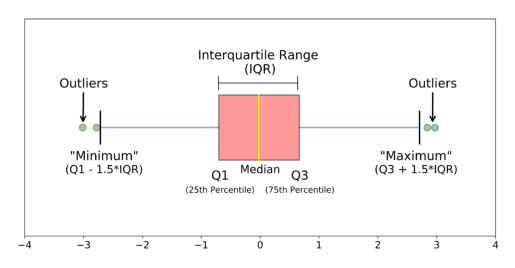

In [94]:
# Imagem
img_dsa = mpimg.imread('outliers.png')
plt.imshow(img_dsa)
plt.axis('off')
plt.show()

In [95]:
dataset_dsa_limpo.shape

(146887, 46)

In [96]:
import pandas as pd
import numpy as np

# Define a classe TrataOutlier
class TrataOutlier:

    # Construtor da classe que inicializa com um DataFrame
    def __init__(self, df: pd.DataFrame) -> None:
        self.df = df

    # Função para contar outliers nas colunas especificadas
    def count_outliers(self, Q1, Q3, IQR, columns):

        # Define o limite de corte para considerar um valor como outlier
        cut_off = IQR * 1.5

        # Cria um DataFrame temporário com valores booleanos indicando outliers
        temp_df = (self.df[columns] < (Q1 - cut_off)) | (self.df[columns] > (Q3 + cut_off))

        # Retorna a contagem de outliers para cada coluna
        return [len(temp_df[temp_df[col] == True]) for col in temp_df]

    # Função para calcular a assimetria das colunas especificadas
    def calc_skew(self, columns=None):

        # Se nenhuma coluna for especificada, utiliza todas as colunas do DataFrame
        if columns == None:
            columns = self.df.columns

        # Retorna a medida de assimetria para cada coluna
        return [self.df[col].skew() for col in columns]

    # Função para calcular a porcentagem dos valores em relação a 146887 (número de linhas até aqui)
    def percentage(self, list):
        return [str(round(((value/146887) * 100), 2)) + '%' for value in list]

    # Função para remover outliers nas colunas especificadas
    def remove_outliers(self, columns):
        for col in columns:

            # Calcula os quantis Q1 e Q3
            Q1, Q3 = self.df[col].quantile(0.25), self.df[col].quantile(0.75)

            # Calcula a amplitude interquartil (IQR)
            IQR = Q3 - Q1

            # Define os limites para considerar um valor como outlier
            cut_off = IQR * 1.5
            lower, upper = Q1 - cut_off, Q3 + cut_off

            # Remove os valores considerados outliers
            self.df = self.df.drop(self.df[self.df[col] > upper].index)
            self.df = self.df.drop(self.df[self.df[col] < lower].index)

    # Função para substituir outliers pelos valores dos fences nas colunas especificadas
    def replace_outliers_with_fences(self, columns):
        for col in columns:

            # Calcula os quantis Q1 e Q3
            Q1, Q3 = self.df[col].quantile(0.25), self.df[col].quantile(0.75)

            # Calcula a amplitude interquartil (IQR)
            IQR = Q3 - Q1

            # Define os limites para considerar um valor como outlier
            cut_off = IQR * 1.5
            lower, upper = Q1 - cut_off, Q3 + cut_off

            # Substitui outliers pelos valores dos fences
            self.df[col] = np.where(self.df[col] > upper, upper, self.df[col])
            self.df[col] = np.where(self.df[col] < lower, lower, self.df[col])

    # Função para obter um resumo estatístico das colunas especificadas
    def getOverview(self, columns) -> None:

        # Calcula diversas estatísticas para as colunas
        min = self.df[columns].min()
        Q1 = self.df[columns].quantile(0.25)
        median = self.df[columns].quantile(0.5)
        Q3 = self.df[columns].quantile(0.75)

        max = self.df[columns].max()
        IQR = Q3 - Q1
        skew = self.calc_skew(columns)
        outliers = self.count_outliers(Q1, Q3, IQR, columns)
        cut_off = IQR * 1.5
        lower, upper = Q1 - cut_off, Q3 + cut_off

        # Define os nomes das colunas para o novo DataFrame
        new_columns = ['Nome de Coluna',
                       'Min',
                       'Q1',
                       'Median',
                       'Q3',
                       'Max',
                       'IQR',
                       'Lower fence',
                       'Upper fence',
                       'Skew',
                       'Num_Outliers',
                       'Percent_Outliers' ]

        # Cria um novo DataFrame com as estatísticas calculadas
        data = zip([column for column in self.df[columns]], min, Q1, median, Q3, max, IQR, lower, upper, skew, outliers, self.percentage(outliers))
        new_df = pd.DataFrame(data = data, columns = new_columns)

        # Define 'Nome de Coluna' como o índice do novo DataFrame
        new_df.set_index('Nome de Coluna', inplace = True)

        # Retorna o novo DataFrame ordenado pelo número de outliers
        return new_df.sort_values('Num_Outliers', ascending = False).transpose()

In [97]:
# Cria o objeto trata outlier
trata_outlier = TrataOutlier(dataset_dsa_limpo)

In [98]:
# Lista de colunas float64
lista_colunas = dataset_dsa_limpo.select_dtypes('float64').columns.tolist()

In [99]:
lista_colunas

['Start Offset (ms)',
 'End Offset (ms)',
 'Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'Activity Duration DL (ms)',
 'Activity Duration UL (ms)',
 'Dur (ms)',
 'Nb of sec with Vol DL < 6250B',
 'Nb of sec with Vol UL < 1250B',
 'Social Media DL (Bytes)',
 'Social Media UL (Bytes)',
 'Google DL (Bytes)',
 'Google UL (Bytes)',
 'Email DL (Bytes)',
 'Email UL (Bytes)',
 'Youtube DL (Bytes)',
 'Youtube UL (Bytes)',
 'Netflix DL (Bytes)',
 'Netflix UL (Bytes)',
 'Gaming DL (Bytes)',
 'Gaming UL (Bytes)',
 'Other DL (Bytes)',
 'Other UL (Bytes)',
 'Total UL (Bytes)',
 'Total DL (Bytes)']

In [100]:
# Visão geral dos outliers
trata_outlier.getOverview(lista_colunas)

Nome de Coluna,DL TP > 1 Mbps (%),10 Kbps < UL TP < 50 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),Activity Duration DL (ms),Activity Duration UL (ms),Nb of sec with Vol UL < 1250B,Nb of sec with Vol DL < 6250B,UL TP < 10 Kbps (%),TCP DL Retrans. Vol (Bytes),Avg Bearer TP UL (kbps),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),Avg RTT UL (ms),Avg RTT DL (ms),50 Kbps < DL TP < 250 Kbps (%),Avg Bearer TP DL (kbps),Dur (ms),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),Total UL (Bytes),Start Offset (ms),End Offset (ms),Social Media DL (Bytes),Google DL (Bytes),Social Media UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Google UL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Gaming DL (Bytes),Netflix UL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total DL (Bytes)
Min,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7142988.0,0.0,0.0,2866892.0,0.0,0.0,12.0,207.0,0.0,14.0,2.0,53.0,3.0,105.0,42.0,2516.0,35.0,59.0,3290.0,148.0,7114041.0
Q1,0.0,0.0,0.0,15418.0,22073.0,107.0,87.0,99.0,24895.0,47.0,3299.5,91.0,2.0,31.0,0.0,43.0,58526863.0,0.0,0.0,33218346.0,250.0,251.0,898089.0,2882586.5,16431.0,892573.0,233439.0,5833462.0,1024371.5,5516549.0,5776625.5,210381659.0,5480202.0,4132622.0,210155459.0,4144551.0,243073402.5
Median,0.0,0.0,0.0,39726.0,47180.0,217.0,201.0,100.0,391635.0,63.0,16436.0,100.0,5.0,44.0,0.0,64.0,86399988.0,0.0,0.0,41143144.0,499.0,500.0,1793409.0,5766724.0,32908.0,1793613.0,466357.0,11616334.0,2054793.0,11013447.0,11642708.0,423492394.0,10999348.0,8294516.0,421633232.0,8265817.0,455963875.0
Q3,0.0,0.0,1.0,697298.5,611803.0,2466.5,2612.5,100.0,3078146.0,1136.0,68622.0,100.0,13.0,67.0,4.0,20024.0,133159382.0,0.0,0.0,49034880.0,749.0,750.0,2694640.0,8625551.0,49326.5,2689818.0,700297.5,17440635.5,3088071.5,16514278.0,17469653.0,633333998.5,16503222.5,12432390.5,631361047.5,12382039.5,665783068.0
Max,94.0,98.0,76.0,136536461.0,144911293.0,604122.0,604061.0,100.0,4294425570.0,58613.0,2908226006.0,100.0,7120.0,96923.0,93.0,378160.0,1859336442.0,85.0,96.0,78331311.0,999.0,999.0,3586064.0,11462832.0,65870.0,3586146.0,936418.0,23259098.0,4121357.0,22011962.0,23259189.0,843441889.0,22011955.0,16558794.0,843442489.0,16558816.0,902969616.0
IQR,0.0,0.0,1.0,681880.5,589730.0,2359.5,2525.5,1.0,3053251.0,1089.0,65322.5,9.0,11.0,36.0,4.0,19981.0,74632519.0,0.0,0.0,15816534.0,499.0,499.0,1796551.0,5742964.5,32895.5,1797245.0,466858.5,11607173.5,2063700.0,10997729.0,11693027.5,422952339.5,11023020.5,8299768.5,421205588.5,8237488.5,422709665.5
Lower fence,0.0,0.0,-1.5,-1007402.75,-862522.0,-3432.25,-3701.25,97.5,-4554981.5,-1586.5,-94684.25,77.5,-14.5,-23.0,-6.0,-29928.5,-53421915.5,0.0,0.0,9493545.0,-498.5,-497.5,-1796737.5,-5731860.25,-32912.25,-1803294.5,-466848.75,-11577298.25,-2071178.5,-10980044.5,-11762915.75,-424046850.25,-11054328.75,-8317030.75,-421652923.75,-8211681.75,-390991095.75
Upper fence,0.0,0.0,2.5,1720119.25,1496398.0,6005.75,6400.75,101.5,7658022.5,2769.5,166605.75,113.5,29.5,121.0,10.0,49995.5,245108160.5,0.0,0.0,72759681.0,1497.5,1498.5,5389466.5,17239997.75,98669.75,5385685.5,1400585.25,34851395.75,6183621.5,33010871.5,35009194.25,1267762507.75,33037753.25,24882043.25,1263169430.25,24738272.25,1299847566.25
Skew,5.345557,10.941071,4.503234,5.821286,7.321154,7.467915,9.009273,-8.958674,16.755094,4.473627,96.168844,-2.293488,26.544463,68.322057,3.273684,2.57405,3.946116,21.051707,35.993888,-0.001944,0.000823,-0.001251,-0.001633,-0.008414,0.000258,-0.002659,0.007312,0.000119,0.002242,-0.001265,-0.002172,-0.003914,-0.000273,-0.002566,0.001832,0.001481,-0.003579
Num_Outliers,36594,31509,29343,26126,25501,24870,24604,21811,21625,21104,20367,18114,16278,16181,14955,12678,7057,4476,2425,241,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [101]:
# Replace dos outliers
trata_outlier.replace_outliers_with_fences(lista_colunas)

In [102]:
# Visão geral dos outliers
trata_outlier.getOverview(lista_colunas)

Nome de Coluna,Start Offset (ms),End Offset (ms),Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),Activity Duration DL (ms),Activity Duration UL (ms),Dur (ms),Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
Min,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,77.5,0.0,0.0,0.0,97.5,0.0,0.0,0.0,0.0,0.0,7142988.0,1.0,1.0,12.0,0.0,207.0,3.0,14.0,2.0,53.0,105.0,42.0,35.0,2516.0,59.0,3290.0,148.0,9493545.0,7114041.0
Q1,250.0,251.0,31.0,2.0,43.0,47.0,24895.0,3299.5,91.0,0.0,0.0,0.0,99.0,0.0,0.0,0.0,15418.0,22073.0,58526863.0,87.0,107.0,898089.0,16431.0,2882586.5,1024371.5,892573.0,233439.0,5833462.0,5516549.0,5776625.5,5480202.0,210381659.0,4132622.0,210155459.0,4144551.0,33218346.0,243073402.5
Median,499.0,500.0,44.0,5.0,64.0,63.0,391635.0,16436.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,39726.0,47180.0,86399988.0,201.0,217.0,1793409.0,32908.0,5766724.0,2054793.0,1793613.0,466357.0,11616334.0,11013447.0,11642708.0,10999348.0,423492394.0,8294516.0,421633232.0,8265817.0,41143144.0,455963875.0
Q3,749.0,750.0,67.0,13.0,20024.0,1136.0,3078146.0,68622.0,100.0,4.0,1.0,0.0,100.0,0.0,0.0,0.0,697298.5,611803.0,133159382.0,2612.5,2466.5,2694640.0,49326.5,8625551.0,3088071.5,2689818.0,700297.5,17440635.5,16514278.0,17469653.0,16503222.5,633333998.5,12432390.5,631361047.5,12382039.5,49034880.0,665783068.0
Max,999.0,999.0,121.0,29.5,49995.5,2769.5,7658022.5,166605.75,100.0,10.0,2.5,0.0,100.0,0.0,0.0,0.0,1720119.25,1496398.0,245108160.5,6400.75,6005.75,3586064.0,65870.0,11462832.0,4121357.0,3586146.0,936418.0,23259098.0,22011962.0,23259189.0,22011955.0,843441889.0,16558794.0,843442489.0,16558816.0,72759681.0,902969616.0
IQR,499.0,499.0,36.0,11.0,19981.0,1089.0,3053251.0,65322.5,9.0,4.0,1.0,0.0,1.0,0.0,0.0,0.0,681880.5,589730.0,74632519.0,2525.5,2359.5,1796551.0,32895.5,5742964.5,2063700.0,1797245.0,466858.5,11607173.5,10997729.0,11693027.5,11023020.5,422952339.5,8299768.5,421205588.5,8237488.5,15816534.0,422709665.5
Lower fence,-498.5,-497.5,-23.0,-14.5,-29928.5,-1586.5,-4554981.5,-94684.25,77.5,-6.0,-1.5,0.0,97.5,0.0,0.0,0.0,-1007402.75,-862522.0,-53421915.5,-3701.25,-3432.25,-1796737.5,-32912.25,-5731860.25,-2071178.5,-1803294.5,-466848.75,-11577298.25,-10980044.5,-11762915.75,-11054328.75,-424046850.25,-8317030.75,-421652923.75,-8211681.75,9493545.0,-390991095.75
Upper fence,1497.5,1498.5,121.0,29.5,49995.5,2769.5,7658022.5,166605.75,113.5,10.0,2.5,0.0,101.5,0.0,0.0,0.0,1720119.25,1496398.0,245108160.5,6400.75,6005.75,5389466.5,98669.75,17239997.75,6183621.5,5385685.5,1400585.25,34851395.75,33010871.5,35009194.25,33037753.25,1267762507.75,24882043.25,1263169430.25,24738272.25,72759681.0,1299847566.25
Skew,0.000823,-0.001251,1.069479,1.165443,1.280613,1.230407,1.216388,1.20234,-1.22817,1.315047,1.098748,0.0,-0.947267,0.0,0.0,0.0,1.205281,1.207483,0.810422,1.205814,1.209533,-0.001633,0.000258,-0.008414,0.002242,-0.002659,0.007312,0.000119,-0.001265,-0.002172,-0.000273,-0.003914,-0.002566,0.001832,0.001481,-0.001978,-0.003579
Num_Outliers,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Entregando o Resultado da Análise aos Tomadores de Decisão

Ter a soma dos volumes de dados de upload e download para cada aplicativo como um total pode ser necessário para análises?

In [103]:
dataset_dsa_limpo['Social Media Data Volume (Bytes)'] = dataset_dsa_limpo['Social Media UL (Bytes)'] + dataset_dsa_limpo['Social Media DL (Bytes)']

In [104]:
dataset_dsa_limpo['Google Data Volume (Bytes)'] = dataset_dsa_limpo['Google UL (Bytes)'] + dataset_dsa_limpo['Google DL (Bytes)']

In [105]:
dataset_dsa_limpo['Email Data Volume (Bytes)'] = dataset_dsa_limpo['Email UL (Bytes)'] + dataset_dsa_limpo['Email DL (Bytes)']

In [106]:
dataset_dsa_limpo['Youtube Data Volume (Bytes)'] = dataset_dsa_limpo['Youtube UL (Bytes)'] + dataset_dsa_limpo['Youtube DL (Bytes)']

In [107]:
dataset_dsa_limpo['Netflix Data Volume (Bytes)'] = dataset_dsa_limpo['Netflix UL (Bytes)'] + dataset_dsa_limpo['Netflix DL (Bytes)']

In [108]:
dataset_dsa_limpo['Gaming Data Volume (Bytes)'] = dataset_dsa_limpo['Gaming UL (Bytes)'] + dataset_dsa_limpo['Gaming DL (Bytes)']

In [109]:
dataset_dsa_limpo['Other Data Volume (Bytes)'] = dataset_dsa_limpo['Other UL (Bytes)'] + dataset_dsa_limpo['Other DL (Bytes)']

In [110]:
dataset_dsa_limpo['Total Data Volume (Bytes)'] = dataset_dsa_limpo['Total UL (Bytes)'] + dataset_dsa_limpo['Total DL (Bytes)']

In [111]:
dataset_dsa_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146887 entries, 0 to 149995
Data columns (total 54 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Bearer Id                         146887 non-null  int64         
 1   Start                             146887 non-null  datetime64[ns]
 2   Start Offset (ms)                 146887 non-null  float64       
 3   End                               146887 non-null  datetime64[ns]
 4   End Offset (ms)                   146887 non-null  float64       
 5   IMSI                              146887 non-null  int64         
 6   MSISDN/Number                     146887 non-null  int64         
 7   IMEI                              146887 non-null  int64         
 8   Last Location Name                146887 non-null  string        
 9   Avg RTT DL (ms)                   146887 non-null  float64       
 10  Avg RTT UL (ms)                   146

In [112]:
dataset_dsa_limpo.shape

(146887, 54)

In [113]:
dataset_dsa_limpo.head()

,Bearer Id,Start,Start Offset (ms),End,End Offset (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),Activity Duration DL (ms),Activity Duration UL (ms),Dur (ms),Handset Manufacturer,Handset Type,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes),Social Media Data Volume (Bytes),Google Data Volume (Bytes),Email Data Volume (Bytes),Youtube Data Volume (Bytes),Netflix Data Volume (Bytes),Gaming Data Volume (Bytes),Other Data Volume (Bytes),Total Data Volume (Bytes)
0,-9223372036854775808,2019-04-04 12:01:00,770.0,2019-04-25 14:35:00,662.0,208201448079117,33664962239,35521209507511,9.16456699548519E+015,42.0,5.0,23.0,44.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,37624.0,38787.0,245108160.5,Samsung,Samsung Galaxy A5 Sm-A520F,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0,1570185.0,2905912.0,3701304.0,18355943.0,17855187.0,292426453.0,180558843.0,345629377.0
1,-9223372036854775808,2019-04-09 13:04:00,235.0,2019-04-25 08:15:00,606.0,208201909211140,33681854413,35794009006359,L77566A,65.0,5.0,16.0,26.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,168.0,3560.0,245108160.5,Samsung,Samsung Galaxy J5 (Sm-J530),971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0,1933278.0,4414096.0,937385.0,39359124.0,35565545.0,609920783.0,541959383.0,707185356.0
2,-9223372036854775808,2019-04-09 17:42:00,1.0,2019-04-25 11:58:00,652.0,208200314458056,33760627129,35281510359387,D42335A,65.0,5.0,6.0,9.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,245108160.5,Samsung,Samsung Galaxy A8 (2018),751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0,1726277.0,10229119.0,3363124.0,34425237.0,23751202.0,229980251.0,414908351.0,307690973.0
3,-9223372036854775808,2019-04-10 00:31:00,486.0,2019-04-25 07:36:00,171.0,208201402342131,33750343200,35356610164913,T21824A,65.0,5.0,44.0,44.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,3330.0,37882.0,245108160.5,unknown,unknown,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0,657493.0,11811761.0,2070983.0,36534765.0,15092588.0,810387875.0,761837216.0,889352748.0
4,-9223372036854775808,2019-04-12 20:10:00,565.0,2019-04-25 10:40:00,954.0,208201401415120,33699795932,35407009745539,D88865A,65.0,5.0,6.0,9.0,19520.0,7230.0,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,245108160.5,Samsung,Samsung Sm-G390F,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0,912788.0,7748843.0,2110349.0,34222253.0,17539799.0,531237049.0,564619822.0,607681403.0


## Salvando os Dados Após a Limpeza

<!-- Projeto Desenvolvido na Data Science Academy - www.datascienceacademy.com.br -->

In [114]:
# Salvando os dados
dataset_dsa_limpo.to_csv('dataset_limpo.csv')

In [115]:
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [116]:
#%watermark

In [117]:
#%watermark --iversions

# Fim